# Student Depression Model
## Jesús Alejandro Pérez Granados                 A01253993
(Este documento tiene contenido tanto en español como inglés)

Este dataset recopila información, de diferentes universidades, de personas (en su mayoría estudiantes) y diferentes factores de su vida y su salud mental. El dataset cuenta con 27901 entradas (personas) y 18 columnas de características de ellas. En la variable que dirigiremos nuestros esfuerzos es la binaria "Depression". Esta indica si la persona sufre de depresión (1 si sí, 0 si no). 

El objetivo de nuestro análisis es producir un modelo predictivo para la depresión, tomando en cuenta las limitaciones que este puede tener por razones obvias.

El dataset es tomado de Kaggle, publicado por Adil Shamim.

In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import plot_tree
from sklearn.model_selection  import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize, StandardScaler
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv("datasets/student_depression_dataset.csv")
df.columns

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='str')

## Preparación de Datos

Siempre es importante realizar una preparación de datos, sin importar cuan "perfectos" estén. Incluso si no poseen errores, es necesario adaptar la base de datos al enfoque de nuestro análisis y transformar s¿ciertas variables.

Como nuestro propósito es predecir la variable depresión, removeremos el id que es irrelevante. Del mismo modo, la ciudad cuenta con demasiadas diferentes que dificultarán el análisis, además que no suscitan a acciones concretas (a menos que se concentre mucho en una sola ciudad) y generará más ruido de lo que ayudará. Remover estos también mantienen confidencialidad.

In [3]:
df = df.drop(columns=['id', 'City'])
print(len(df), "entradas")
df.head()

27901 entradas


,Gender,Age,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,Female,24.0,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,Male,31.0,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,Female,28.0,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,Female,25.0,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


Solo nos interesan los estudiantes en este caso, por lo que nos quedaremos con un dataset compuesto solamente de estudiantes.

In [4]:
students = df[df['Profession'] == 'Student']
print("El nuevo dataset contiene", len(students), "etudiantes")
students['Profession'].unique()

El nuevo dataset contiene 27870 etudiantes


<StringArray>
['Student']
Length: 1, dtype: str

In [5]:
students = students.drop(columns='Profession')
students.info()

<class 'pandas.DataFrame'>
Index: 27870 entries, 0 to 27900
Data columns (total 15 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 27870 non-null  str    
 1   Age                                    27870 non-null  float64
 2   Academic Pressure                      27870 non-null  float64
 3   Work Pressure                          27870 non-null  float64
 4   CGPA                                   27870 non-null  float64
 5   Study Satisfaction                     27870 non-null  float64
 6   Job Satisfaction                       27870 non-null  float64
 7   Sleep Duration                         27870 non-null  str    
 8   Dietary Habits                         27870 non-null  str    
 9   Degree                                 27870 non-null  str    
 10  Have you ever had suicidal thoughts ?  27870 non-null  str    
 11  Work/Study Hours  

Como se había mencionado, en su mayoría son estudiantes. Para continuar, debemos notar si los datos muestran algún desbalanceo de clases. La crucial a comparar es de quienes tienen y no tienen depresión. También, analizaremos si hay desbalance entre hombres y mujeres estudiadas.

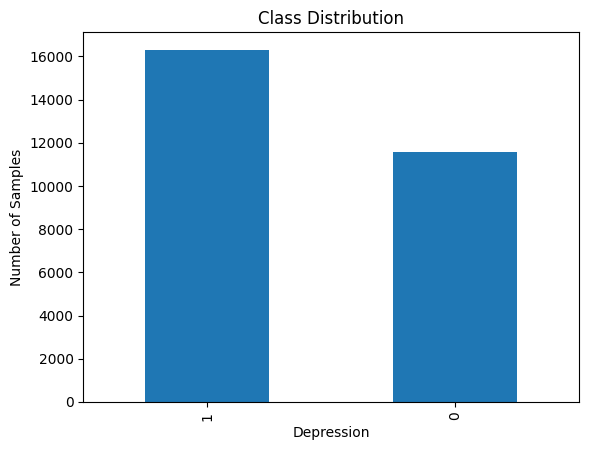

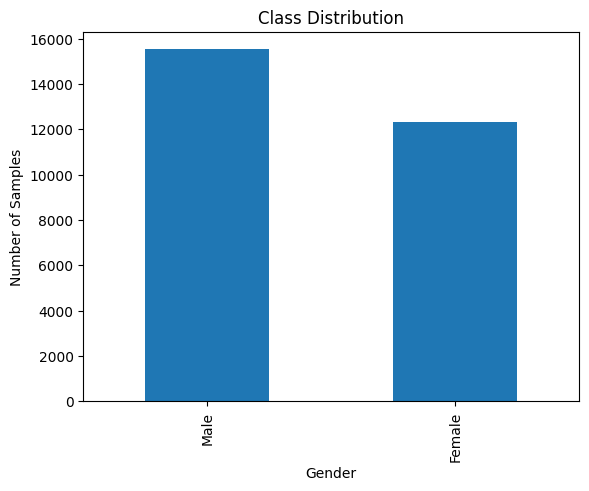

In [6]:
depression_frequency = students['Depression'].value_counts()

depression_frequency.plot(kind='bar')

plt.xlabel("Depression")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")
plt.show()

gender_frequency = students['Gender'].value_counts()

gender_frequency.plot(kind='bar')

plt.xlabel("Gender")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")
plt.show()

Ambos grupos se consideran balanceados (en términos de Data Science y problemas de baja representación), por lo que no es necesario rebalanceo de las clases. Sin embargo, al sí tener diferencia proporcional (aunque mínima), se deberá hacer test y tran splits estratificados de depresión y por género, para sí reflejar la disparidad de estos datos. Antes de esto, es importante adaptar ciertas variables clasificatorias y binarias para que funcionen con cualquier modelo.

In [7]:
students = pd.get_dummies(students, columns=['Gender', 'Sleep Duration', 'Dietary Habits', 'Degree'], drop_first=True)

# Ahora algunos binarios simples
students['Have you ever had suicidal thoughts ?'] = students['Have you ever had suicidal thoughts ?'].map({'Yes': 1, 'No': 0})
students['Family History of Mental Illness'] = students['Family History of Mental Illness'].map({'Yes': 1, 'No': 0})
students.info()

<class 'pandas.DataFrame'>
Index: 27870 entries, 0 to 27900
Data columns (total 46 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Age                                    27870 non-null  float64
 1   Academic Pressure                      27870 non-null  float64
 2   Work Pressure                          27870 non-null  float64
 3   CGPA                                   27870 non-null  float64
 4   Study Satisfaction                     27870 non-null  float64
 5   Job Satisfaction                       27870 non-null  float64
 6   Have you ever had suicidal thoughts ?  27870 non-null  int64  
 7   Work/Study Hours                       27870 non-null  float64
 8   Financial Stress                       27870 non-null  str    
 9   Family History of Mental Illness       27870 non-null  int64  
 10  Depression                             27870 non-null  int64  
 11  Gender_Male       

In [8]:
# Corregir no numéricos restantes
students['Financial Stress'] = pd.to_numeric(students['Financial Stress'], errors='coerce')
students.info()

<class 'pandas.DataFrame'>
Index: 27870 entries, 0 to 27900
Data columns (total 46 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Age                                    27870 non-null  float64
 1   Academic Pressure                      27870 non-null  float64
 2   Work Pressure                          27870 non-null  float64
 3   CGPA                                   27870 non-null  float64
 4   Study Satisfaction                     27870 non-null  float64
 5   Job Satisfaction                       27870 non-null  float64
 6   Have you ever had suicidal thoughts ?  27870 non-null  int64  
 7   Work/Study Hours                       27870 non-null  float64
 8   Financial Stress                       27867 non-null  float64
 9   Family History of Mental Illness       27870 non-null  int64  
 10  Depression                             27870 non-null  int64  
 11  Gender_Male       

Esto nos dejó con 3 NANs en Financial Stress. Son tan pocos que es mejor eliminarlos.

In [9]:
students = students.dropna()

Ahora sí haremos el split. Para ello generaremos una nueva columna.

In [10]:
students['estratificacion'] = students['Gender_Male'].astype(str) + "_" + df['Depression'].astype(str)

X = students.drop(columns = ['Depression', 'estratificacion'])
y = students['Depression']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42, 
    stratify=students['estratificacion']
)

Ya con esto se preparan generalmente los datos (para ciertos modelos quizá se necesite más adaptación).

# Modelación

The problem we are addressing is that of medical diagnosis. It is necessary to employ a classification model since we are addressing a binary result of either depression and not depression. There are also regression models (logistic regression) for binary outputs, but it handles linear relationships.

Due to the nature of depression and it being a more complex problem that can't be expressed linearly (maybe not even non-linearly with total accuracy), we must use classification models that better express this complex diagnosis that is depression.

## Random Forest

Aquí los datos no necesitan más preparación que la que ya se hizo. Random Forest trabaja con umbrales en lugar de gradientes o distancias entre los datos. Las escalas no afectan a su funcionalidad.

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 150}


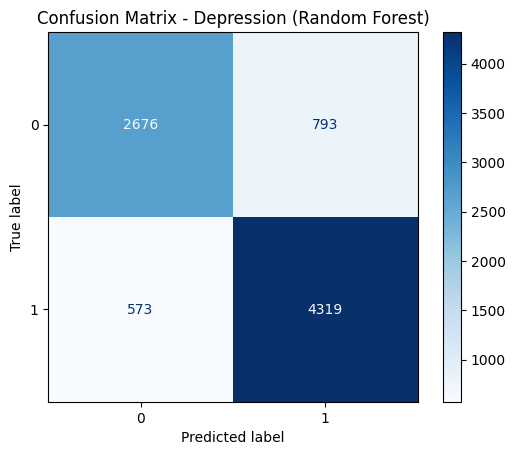

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.77      0.80      3469
           1       0.84      0.88      0.86      4892

    accuracy                           0.84      8361
   macro avg       0.83      0.83      0.83      8361
weighted avg       0.84      0.84      0.84      8361



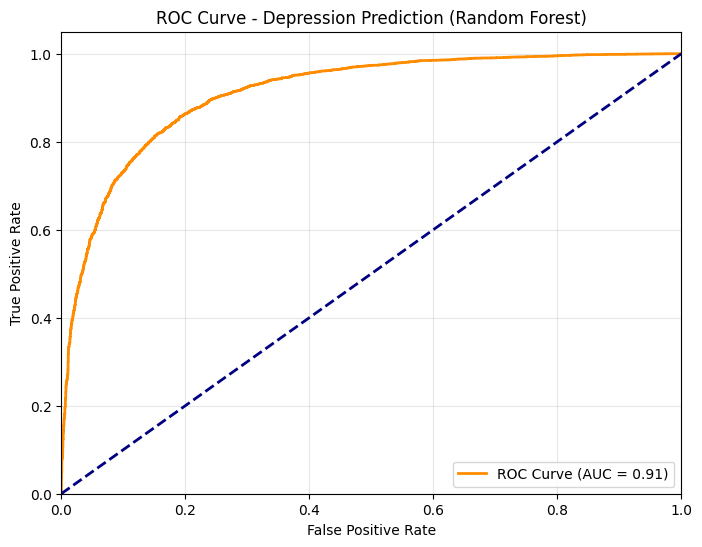

In [12]:
# Hyperparameter grid for random forest
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3,5,7,None],
    'min_samples_split': [2,4,6],
    'min_samples_leaf': [1,2,4],
    'max_features': [None, 'sqrt', 'log2'],
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator = rf,  param_grid=param_grid, cv=5, scoring="accuracy", n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("Best hyperparameters:", grid_search.best_params_)

y_pred = best_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Depression (Random Forest)")
plt.show()

# Classification report
report = classification_report(y_test, y_pred, labels = best_model.classes_)
print("Classification Report:")
print(report)

y_score = best_model.predict_proba(X_test)[:, 1]

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# Graficar Resultados
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Depression Prediction (Random Forest)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Los resultados revelan una alta funcionalidad del modelo. Aunque la accuracy es 0.84, recordemos que el recall de aquellos con depresión es más importante; queremos saber a cuantas personas que sí tienen depresión detectaremos (alrededor de un 88%). Claro, también son importantes los falsos positivos, pero, en este caso, es más importante la cantidad de personas que necesitan ayuda y no la obtienen.

## Support Vector Machine

Se utilizará este modelo por la naturaleza binaria de la variable dependiente, en la cual SVM se especializa. En este caso, SVM sí es influenciado por las escalas de los datos, por lo que usaremos un standard scaler (se usa con un pipeline y así se hace dentro del grid_search).

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Mejores hiperparámetros: {'svm__C': 0.1, 'svm__gamma': 'auto', 'svm__kernel': 'rbf'}


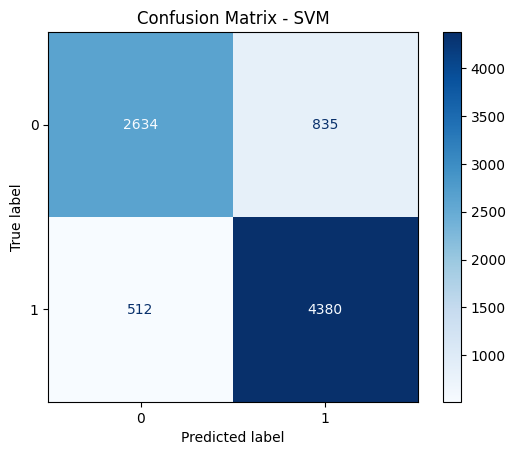

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.76      0.80      3469
           1       0.84      0.90      0.87      4892

    accuracy                           0.84      8361
   macro avg       0.84      0.83      0.83      8361
weighted avg       0.84      0.84      0.84      8361



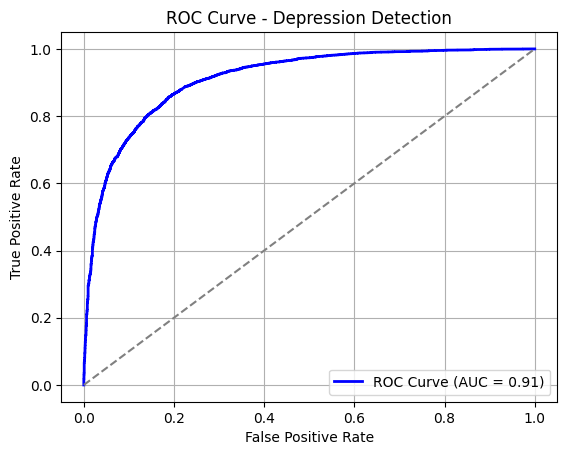

In [14]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, random_state=42))
])
param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__kernel': ['rbf', 'poly'],
    'svm__gamma': ['auto', 'scale']
}

grid_search = GridSearchCV(
    estimator=pipe, 
    param_grid=param_grid, 
    cv=5, 
    scoring="accuracy", 
    n_jobs=-1, 
    verbose=1
)

grid_search.fit(X_train, y_train)

# Resultados
best_model = grid_search.best_estimator_
print("Mejores hiperparámetros:", grid_search.best_params_)

y_pred = best_model.predict(X_test)



# Graficas y reportes

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred, labels=best_model.named_steps['svm'].classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.named_steps['svm'].classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - SVM")
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Curva ROC
y_score = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score) # Usamos y_test directamente
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Depression Detection')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

De nuevo, lo que consideramos más importante es sí es detectar a las personas con depresión. Este tiene la misma accuracy que la anterior, pero posee un mayor recall en personas con depresión (es decir, tiene mayor porcentaje de detección acertada en personas con depresión).

# Conclusiones
It can be seen both models had a great performance on the testing data. With high accuracy, these models had an AUC of Receiving Operating Characteristic of 0.91, meaning that they to predict data with high accuracy. On one hand, the Random Forest had high accuracy, recall, precision and F1 score. This model was highly effective do to the consideration of numerous variables and its extensive, arduous approach to classification. On the other hand, SVM reflected this same level of accuracy and high values as well across the report. It is equal or higher on all values, except for non-depressive recall (for 1%). More importantly though, it has 2% higher recall on people with depression, which really is the most important metric for this topic. It is crucial to find the most people that do have depression (obviously also while not having many false positives, but it's minimal), since it is better to help a few people who don't "need it", than to help less who do.

In conclusion, both SVM and Random Forest generated great models for predicting depression in students. SVM showed to be a little better for the context of this problem. This could be due to the fact that it considers both linear and nonlinear connections; the complexities of depression while also using the fact that there are linear patterns in behavior. Random Forest, however, showed to be a lot faster in its processes while maintaining high precision on its model. This jsut goes to show there is no universal answer for anything. One might take a certain model if they need to prioritize resources and still be accurate, while others may look for highest performance. Just like depression, nothing is just a checkbox.